In [271]:
import sys
sys.path.insert(0, '../../gofher')

import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import gmean

from galaxy_band_pair import construct_galaxy_band_pair_key
import itertools

In [272]:
BANDS_IN_ORDER = ['g','r','i','z'] #Important: Must stay in order of BLUEST to REDDEST Waveband (Editting this will cause gofher to no longer correctly evaluate redder side of galaxy)

path_to_input = "C:\\Users\\school\\Desktop\\gofher_stats_test_sdss"

In [273]:
class band_pair_stats:
    def __init__(self,band_pair_label,row,size_dict={}):
        self.name = row['name']
        self.band_pair = band_pair_label

        self.paper_label = row['paper_label']
        self.label = ""
        self.score = 0
        
        self.mad = np.inf
        self.mannwhitneyu_stat = np.inf
        self.mannwhitneyu_stat_norm = np.inf
        self.mannwhitneyu_pvalue = np.inf
        self.wasserstein_distance = np.inf
        self.laplace_smoothed_kld = np.inf

        self._populate_data(row,size_dict)
    
    def _populate_data(self,row,size_dict={}):
        self.label = row[f"{self.band_pair}_label"]
        self.score = row[f"{self.band_pair}_score"]

        self.mad = abs(row[f"{self.band_pair}_mean_diff"])
        self.mannwhitneyu_stat = row[f"{self.band_pair}_mannwhitneyu_stat"]
        self.mannwhitneyu_pvalue = row[f"{self.band_pair}_mannwhitneyu_pval"]
        self.wasserstein_distance = row[f"{self.band_pair}_wasserstein_distance"]
        self.laplace_smoothed_kld = row[f"{self.band_pair}_laplace_smoothed_kld"]

        if self.name not in size_dict: return
        self.mannwhitneyu_stat_norm = self.mannwhitneyu_stat/size_dict[self.name]

def get_band_pair_keys():
    band_pair_keys = []
    for (blue_band,red_band) in itertools.combinations(BANDS_IN_ORDER, 2):
        band_pair_keys.append(construct_galaxy_band_pair_key(blue_band,red_band))
    return band_pair_keys
    

def get_csv_data(figure,size_dict={}):
    data = []
    band_pair_keys = get_band_pair_keys()
    
    df = pd.read_csv(os.path.join(path_to_input, "{}_verbose.csv".format(figure)))
    for index, row in df.iterrows():
        for each_band_pair in band_pair_keys:
            data.append(band_pair_stats(each_band_pair,row,size_dict))
    return data

def get_ellipse_size_from_csv_data(figure):
    size_dict = dict()
    df = pd.read_csv(os.path.join(path_to_input, "{}_params.csv".format(figure)))
    for index, row in df.iterrows():
            name = row['name']
            a = row['a']
            b = row['b']
            size_dict[name] = a*b*np.pi
    return size_dict

def split_data_by_score(data):
    pos_ones = []
    zeros = []
    neg_ones = []

    for each in data:
        if each.score == 1:
            pos_ones.append(each)
        elif each.score == -1:
            neg_ones.append(each)
        else:
            zeros.append(each)
    
    return pos_ones, zeros, neg_ones

In [274]:
def mean_and_std(data):
    pos_ones, zeros, neg_ones = split_data_by_score(data)

    votes = {'agree': pos_ones, 'disagree': neg_ones, 'no vote': zeros}
    for vote in votes:
        means = []
        for each_gal_stats in votes[vote]:
            means.append(each_gal_stats.mad)
        print(f"{vote}: {len(means)} mean {np.mean(means)} std {np.std(means)}")
        plt.hist(means)
        plt.title(vote)
        plt.show()

def compare_x_and_y(data, x, y, label =''):
    pos_ones, zeros, neg_ones = split_data_by_score(data)
    votes = {'agree': pos_ones, 'disagree': neg_ones}
    for vote in votes:
        xs = []
        ys = []
        for each_gal_stats in votes[vote]:
            xs.append(x(each_gal_stats))
            ys.append(y(each_gal_stats))

        print(f"{vote}: {len(xs)} mean {gmean(xs)} std {np.std(xs)} mean {np.mean(ys)} std {np.std(ys)}")
        plt.scatter(xs,ys,alpha=0.2)
    plt.title(f"{vote} {label}")
    plt.show()

def compare_mean_vs_mannwhitneyu(data):
    mean_lambda = lambda x: x.mad
    mwu_lambda = lambda x: x.mannwhitneyu_stat
    compare_x_and_y(data, mean_lambda, mwu_lambda, label ='mad vs. mwu')

def compare_mean_vs_wasserstein_distance(data):
    mean_lambda = lambda x: x.mad
    was_lambda = lambda x: x.wasserstein_distance
    compare_x_and_y(data, mean_lambda, was_lambda, label ='man vs. was')

def compare_mean_vs_laplace_smoothed_kld(data):
    mad_lambda = lambda x: x.mad
    kld_lambda = lambda x: x.laplace_smoothed_kld
    compare_x_and_y(data, mad_lambda, kld_lambda, label ='man vs. kld')

def compare_wasserstein_vs_laplace_smoothed_kld(data):
    was_lambda = lambda x: x.wasserstein_distance
    kld_lambda = lambda x: x.laplace_smoothed_kld
    compare_x_and_y(data, was_lambda, kld_lambda, label ='was vs. kld')

def compare_mannwhitneyu_vs_laplace_smoothed_kld(data):
    mwu_lambda = lambda x: x.mannwhitneyu_stat
    kld_lambda = lambda x: x.laplace_smoothed_kld
    compare_x_and_y(data, mwu_lambda, kld_lambda, label ='mwu vs. kld')

In [275]:
def compare_mannwhitneyu_norm_vs_mannwhitneyu(data):
    mwun_lambda = lambda x: x.mannwhitneyu_stat_norm
    mwu_lambda = lambda x: x.mannwhitneyu_stat
    compare_x_and_y(data, mwun_lambda, mwu_lambda, label ='mad vs. mwu')

def compare_mannwhitneyu_norm_vs_p_val(data):
    mwu_lambda = lambda x: x.mannwhitneyu_stat_norm
    kld_lambda = lambda x: x.mannwhitneyu_pvalue
    compare_x_and_y(data, mwu_lambda, kld_lambda, label ='mwu norm vs. pvalue')

def compare_mean_vs_mannwhitneyu_norm(data):
    mean_lambda = lambda x: x.mad
    mwun_lambda = lambda x: x.mannwhitneyu_stat_norm
    compare_x_and_y(data, mean_lambda, mwun_lambda, label ='mad vs. mwu norm')

def compare_wasserstein_mannwhitneyu_norm(data):
    was_lambda = lambda x: x.wasserstein_distance
    mwun_lambda = lambda x: x.mannwhitneyu_stat_norm
    compare_x_and_y(data, was_lambda, mwun_lambda, label ='mad vs. mwu norm')

def compare_mannwhitneyu_norm_vs_laplace_smoothed_kld(data):
    mwu_lambda = lambda x: x.mannwhitneyu_stat_norm
    kld_lambda = lambda x: x.laplace_smoothed_kld
    compare_x_and_y(data, mwu_lambda, kld_lambda, label ='mwu norm vs. kld')

In [276]:
figure_8_size_dict = get_ellipse_size_from_csv_data("figure8")
figure_10_size_dict = get_ellipse_size_from_csv_data("figure10")
figure_11_size_dict = get_ellipse_size_from_csv_data("figure11")

agree: 999 mean 0.009030449155782988 std 0.01753165664704248 mean 0.015181134663307165 std 0.016281339486198067
disagree: 87 mean 0.002454304281509785 std 0.026647659183242904 mean 0.011156163809437547 std 0.024896607610012247


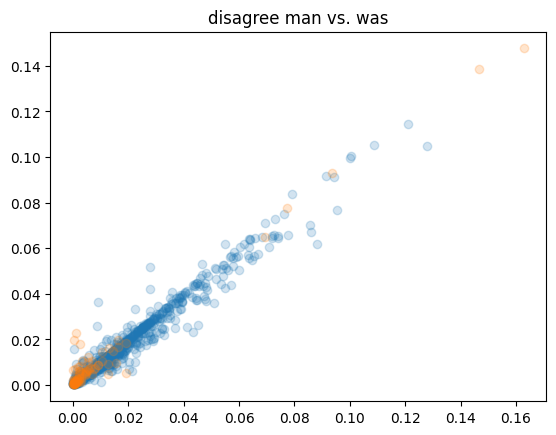

In [277]:
figure_8_results = get_csv_data("figure8",figure_8_size_dict)
figure_10_results = get_csv_data("figure10",figure_10_size_dict)
figure_11_results = get_csv_data("figure11",figure_11_size_dict)


all_results = figure_8_results + figure_10_results + figure_11_results

#mean_and_std(all_results)
#compare_mean_vs_mannwhitneyu(all_results)
compare_mean_vs_wasserstein_distance(all_results)
#compare_mean_vs_laplace_smoothed_kld(all_results)
#compare_wasserstein_vs_laplace_smoothed_kld(all_results)
#compare_mannwhitneyu_vs_laplace_smoothed_kld(all_results)

#compare_mannwhitneyu_norm_vs_mannwhitneyu(all_results)
#compare_mannwhitneyu_norm_vs_p_val(all_results)
#compare_mean_vs_mannwhitneyu_norm(all_results)
#compare_wasserstein_mannwhitneyu_norm(all_results)
#compare_mannwhitneyu_norm_vs_laplace_smoothed_kld(all_results)